# Chapter 08: Hidden Variables and EM

Source orientation: printed pages 179-189; PDF pages 186-196.

This notebook rebuilds the chapter as a computational lesson about what happens when the statistical object we can observe is a shadow of a richer complete-data object. The central algorithm is EM: it alternates between filling in a compatible hidden-variable distribution and refitting the visible model. The visual thread is geometric throughout: alternating projection, Gaussian mixtures, missing information, and misspecification.


## Translation Guide

- A hidden-variable model has complete data `(x, z)` but observations only expose `x`. The missing label or latent coordinate `z` creates a larger complete-data space.
- The E-step builds the conditional distribution of hidden variables under the current parameter, often called responsibilities in mixture models.
- The M-step maximizes the expected complete-data log likelihood under those responsibilities.
- In information-geometric language, the two steps can be read as alternating moves between a family compatible with observed data and a parametric family on complete data.
- Missing information is the gap between what complete data would reveal and what the observed projection reveals.
- Under misspecification, the model is not expected to contain the data-generating distribution; estimation aims at the closest point in the model, usually in KL divergence.


## Route Through The Chapter

1. Draw EM as alternating projection rather than as a black-box optimizer.
2. Implement EM for a one-dimensional Gaussian mixture and visualize responsibilities.
3. Track monotonicity of observed log likelihood and relate it to the auxiliary function.
4. Measure information loss from hiding labels and from coarse observation maps.
5. Run an applied lab where overlap, initialization, and misspecification change the geometry.
6. Save a final sanity JSON that verifies numerical identities and artifact integrity.


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from scipy.special import logsumexp
from scipy.stats import norm
import plotly.graph_objects as go

# Discover the course root without hardcoding a machine-specific path.
HERE = Path.cwd()
for candidate in [HERE, *HERE.parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the course root containing AGENTS.md and utils/.")

import sys
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_record, display_artifact, save_json, save_matplotlib, save_plotly_html

CHAPTER = "chapter-08"
ARTIFACTS = BOOK_ROOT / "artifacts" / CHAPTER
ARTIFACTS.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(8)

plt.rcParams.update({
    "figure.figsize": (7.2, 4.6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## 1. EM As Alternating Projection

A useful mental model is to place complete-data distributions in a large ambient simplex. One subset is determined by the observed empirical distribution: every complete-data distribution in it marginalizes to the data we actually saw. Another subset is the parametric model lifted to complete data. EM alternates between these two descriptions.

The E-step keeps the observed marginal fixed and chooses hidden-conditionals from the current model. The M-step keeps the completed empirical distribution fixed and finds the model point that best matches it. The path is usually not a Euclidean shortest path. Its monotonic behavior comes from a divergence decomposition: the observed likelihood improves because each step solves a local projection problem in the lifted space.


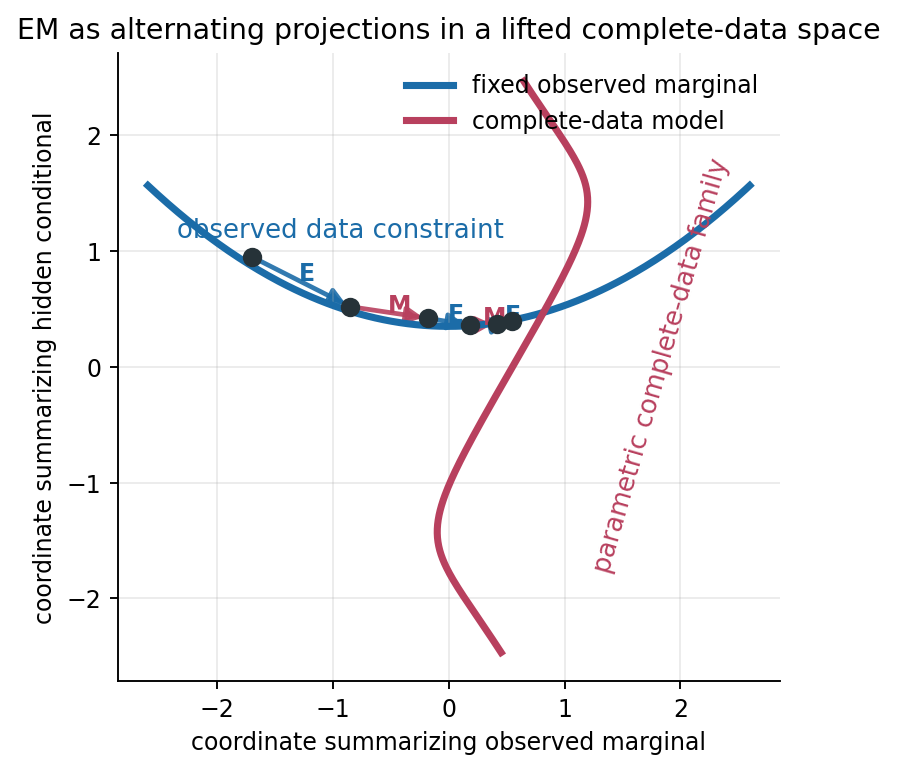

In [2]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))

t = np.linspace(-2.6, 2.6, 300)
observed_x = t
observed_y = 0.18 * t**2 + 0.35
model_x = 0.65 * np.sin(1.15 * t) + 0.55
model_y = t + 0.15 * np.sin(2 * t)

ax.plot(observed_x, observed_y, color="#1b6ca8", lw=3, label="fixed observed marginal")
ax.plot(model_x, model_y, color="#b8405e", lw=3, label="complete-data model")

path = np.array([
    [-1.7, 0.95], [-0.85, 0.52], [-0.18, 0.42], [0.18, 0.36], [0.42, 0.37], [0.55, 0.40]
])
ax.scatter(path[:, 0], path[:, 1], s=52, color="#263238", zorder=4)
for i in range(len(path) - 1):
    color = "#1b6ca8" if i % 2 == 0 else "#b8405e"
    arrow = FancyArrowPatch(path[i], path[i + 1], arrowstyle="-|>", mutation_scale=14,
                            lw=2.0, color=color, alpha=0.9)
    ax.add_patch(arrow)
    ax.text(*(0.52 * path[i] + 0.48 * path[i + 1]), "E" if i % 2 == 0 else "M",
            color=color, fontsize=10, weight="bold")

ax.text(-2.35, 1.12, "observed data constraint", color="#1b6ca8", fontsize=11)
ax.text(1.22, -1.75, "parametric complete-data family", color="#b8405e", fontsize=11, rotation=74)
ax.set_title("EM as alternating projections in a lifted complete-data space")
ax.set_xlabel("coordinate summarizing observed marginal")
ax.set_ylabel("coordinate summarizing hidden conditional")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right", frameon=False)
projection_diagram = save_matplotlib(fig, CHAPTER, "alternating-projection", "em_projection_diagram.png", dpi=170)
plt.close(fig)
display_artifact(projection_diagram, width=760)


The drawing is schematic, but it encodes the computational contract. EM does not invent observed data; it changes hidden completions. It does not keep the hidden completions forever; it immediately projects them back onto the model. This is why the algorithm can be stable even when labels, memberships, or alignments are not observed.


## 2. Gaussian Mixture Laboratory

A Gaussian mixture is the smallest example that makes the hidden-variable story vivid. The visible datum is a scalar `x`. The hidden variable `z` names the component that produced it. If the label were known, maximum likelihood would reduce to weighted sample means and variances. Without the label, EM repeatedly estimates the label probabilities and then performs the same weighted updates.


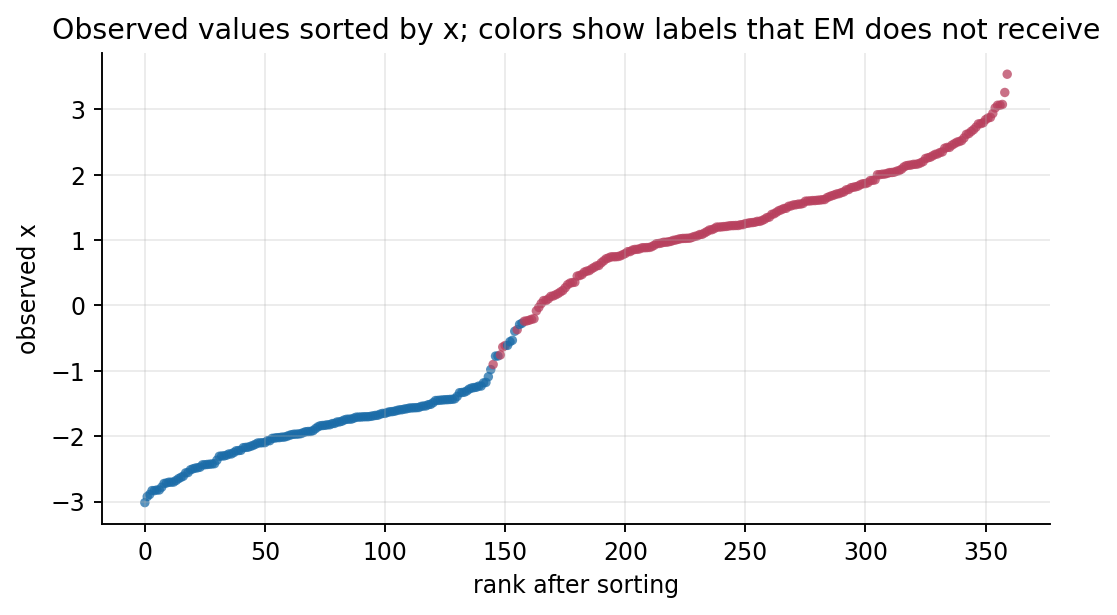

In [3]:
def simulate_mixture(n=360, weights=(0.42, 0.58), means=(-1.9, 1.35), sigmas=(0.58, 0.82), rng=RNG):
    weights = np.asarray(weights, dtype=float)
    z = rng.choice(len(weights), size=n, p=weights)
    x = rng.normal(np.asarray(means)[z], np.asarray(sigmas)[z])
    return x, z

x, true_z = simulate_mixture()
order = np.argsort(x)
x_sorted = x[order]
true_z_sorted = true_z[order]

fig, ax = plt.subplots(figsize=(7.2, 3.6))
colors = np.array(["#1b6ca8", "#b8405e"])
ax.scatter(np.arange(len(x_sorted)), x_sorted, c=colors[true_z_sorted], s=16, alpha=0.75, edgecolor="none")
ax.set_title("Observed values sorted by x; colors show labels that EM does not receive")
ax.set_xlabel("rank after sorting")
ax.set_ylabel("observed x")
raw_data_plot = save_matplotlib(fig, CHAPTER, "gaussian-mixture", "hidden_labels_sorted.png", dpi=170)
plt.close(fig)
display_artifact(raw_data_plot, width=760)


In [4]:
def em_gmm_1d(x, k=2, iterations=34, init_means=(-2.8, 2.6), init_sigmas=(1.25, 1.25), init_weights=None):
    x = np.asarray(x, dtype=float)
    n = x.size
    weights = np.ones(k) / k if init_weights is None else np.asarray(init_weights, dtype=float)
    means = np.asarray(init_means, dtype=float)
    sigmas = np.asarray(init_sigmas, dtype=float)
    history = []

    for it in range(iterations + 1):
        log_component = np.vstack([
            np.log(weights[j] + 1e-15) + norm.logpdf(x, loc=means[j], scale=sigmas[j])
            for j in range(k)
        ]).T
        log_norm = logsumexp(log_component, axis=1, keepdims=True)
        resp = np.exp(log_component - log_norm)
        loglik = float(log_norm.sum())
        history.append({
            "iteration": it,
            "weights": weights.copy(),
            "means": means.copy(),
            "sigmas": sigmas.copy(),
            "responsibilities": resp.copy(),
            "loglik": loglik,
        })
        if it == iterations:
            break
        nk = resp.sum(axis=0)
        weights = nk / n
        means = (resp * x[:, None]).sum(axis=0) / nk
        variances = (resp * (x[:, None] - means) ** 2).sum(axis=0) / nk
        sigmas = np.sqrt(np.maximum(variances, 1e-8))
    return history

history = em_gmm_1d(x)
final = history[-1]
final["weights"], final["means"], final["sigmas"], final["loglik"]


(array([0.41306334, 0.58693666]),
 array([-1.90280317,  1.33730575]),
 array([0.5014369 , 0.88962761]),
 -616.6684234603249)

Responsibilities are conditional probabilities of the hidden label given the observed point and the current parameter. On the mixture boundary, the heatmap is nearly black or nearly bright: labels are almost known. In the overlap region, the same observation can be compatible with both components. That fuzzy band is the missing information made visible.


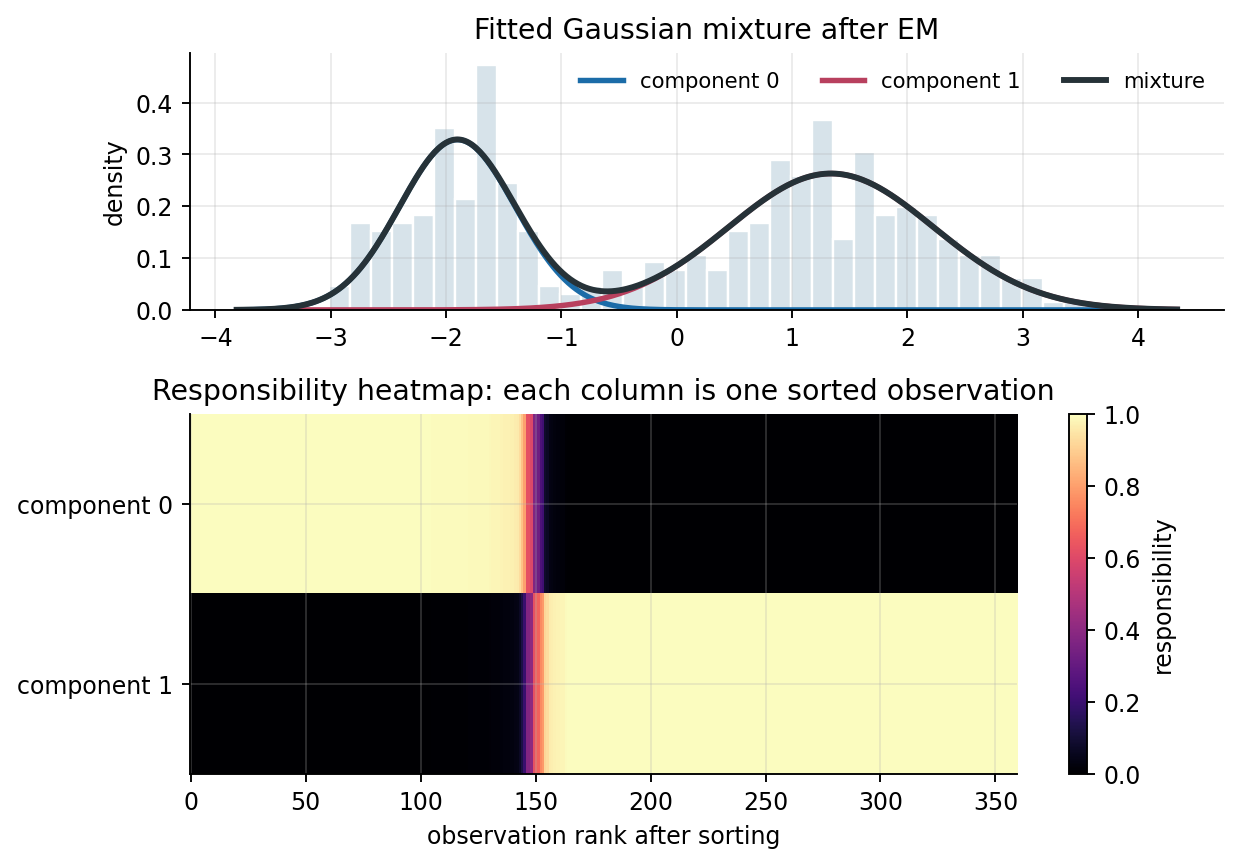

In [5]:
resp_sorted = final["responsibilities"][order]
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7.4, 5.2), gridspec_kw={"height_ratios": [1.0, 1.4]})
ax0.hist(x, bins=36, density=True, color="#d7e3ea", edgecolor="white")
grid = np.linspace(x.min() - 0.8, x.max() + 0.8, 500)
density = np.zeros_like(grid)
for w, m, s, color, label in zip(final["weights"], final["means"], final["sigmas"], ["#1b6ca8", "#b8405e"], ["component 0", "component 1"]):
    comp = w * norm.pdf(grid, m, s)
    density += comp
    ax0.plot(grid, comp, color=color, lw=2.3, label=label)
ax0.plot(grid, density, color="#263238", lw=2.5, label="mixture")
ax0.set_title("Fitted Gaussian mixture after EM")
ax0.set_ylabel("density")
ax0.legend(frameon=False, ncol=3, fontsize=9)

im = ax1.imshow(resp_sorted.T, aspect="auto", cmap="magma", interpolation="nearest", vmin=0, vmax=1)
ax1.set_title("Responsibility heatmap: each column is one sorted observation")
ax1.set_xlabel("observation rank after sorting")
ax1.set_yticks([0, 1], labels=["component 0", "component 1"])
fig.colorbar(im, ax=ax1, label="responsibility")
fig.tight_layout()
responsibility_heatmap = save_matplotlib(fig, CHAPTER, "gaussian-mixture", "responsibility_heatmap.png", dpi=170)
plt.close(fig)
display_artifact(responsibility_heatmap, width=760)


## 3. Monotonicity And The Auxiliary Function

The observed log likelihood is hard because it contains a log of a sum over hidden labels. EM replaces that difficulty with an auxiliary function: hold the current responsibilities fixed, maximize the expected complete-data log likelihood, and then recompute responsibilities. The numerical trace below is the practical signature of the projection picture: the observed log likelihood rises until local improvement becomes negligible.


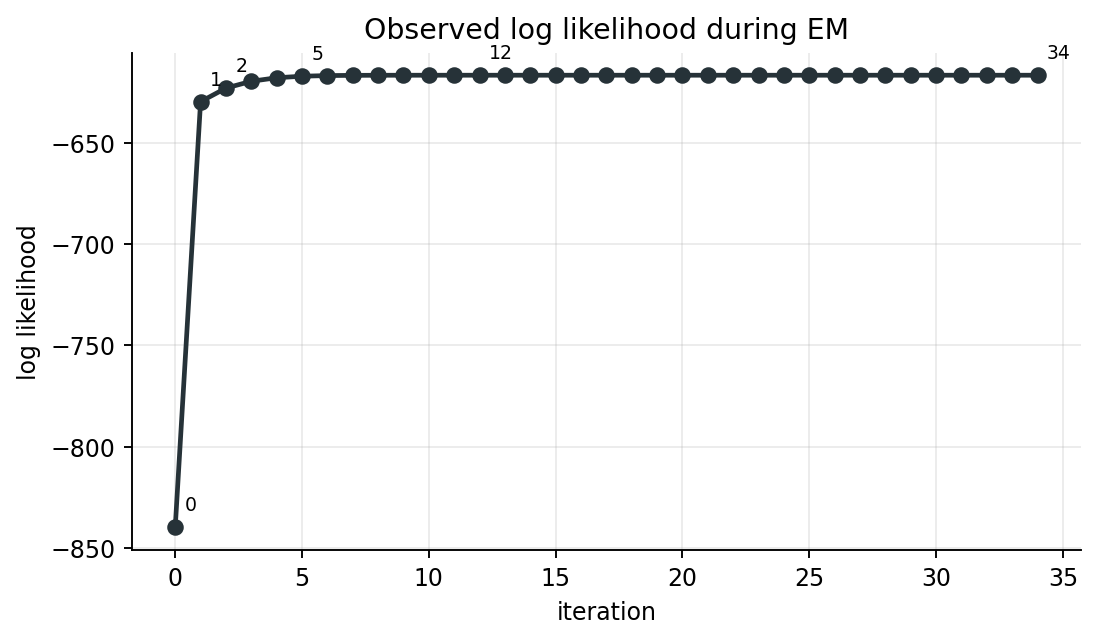

In [6]:
loglik = np.array([h["loglik"] for h in history])
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot([h["iteration"] for h in history], loglik, marker="o", color="#263238", lw=2)
ax.set_title("Observed log likelihood during EM")
ax.set_xlabel("iteration")
ax.set_ylabel("log likelihood")
for idx in [0, 1, 2, 5, 12, len(history) - 1]:
    ax.annotate(str(idx), (idx, loglik[idx]), textcoords="offset points", xytext=(4, 7), fontsize=8)
loglik_trace = save_matplotlib(fig, CHAPTER, "gaussian-mixture", "loglik_trace.png", dpi=170)
plt.close(fig)
display_artifact(loglik_trace, width=760)


In [7]:
# Build a Plotly surface over two means while holding final weights and scales fixed.
m0_grid = np.linspace(final["means"][0] - 1.4, final["means"][0] + 1.4, 54)
m1_grid = np.linspace(final["means"][1] - 1.4, final["means"][1] + 1.4, 54)
Z = np.empty((len(m0_grid), len(m1_grid)))
for i, m0 in enumerate(m0_grid):
    for j, m1 in enumerate(m1_grid):
        comps = np.vstack([
            np.log(final["weights"][0]) + norm.logpdf(x, m0, final["sigmas"][0]),
            np.log(final["weights"][1]) + norm.logpdf(x, m1, final["sigmas"][1]),
        ]).T
        Z[i, j] = logsumexp(comps, axis=1).sum()

path_m0 = [h["means"][0] for h in history]
path_m1 = [h["means"][1] for h in history]
path_z = []
for m0, m1 in zip(path_m0, path_m1):
    comps = np.vstack([
        np.log(final["weights"][0]) + norm.logpdf(x, m0, final["sigmas"][0]),
        np.log(final["weights"][1]) + norm.logpdf(x, m1, final["sigmas"][1]),
    ]).T
    path_z.append(logsumexp(comps, axis=1).sum())

surface = go.Figure(data=[
    go.Surface(x=m1_grid, y=m0_grid, z=Z, colorscale="Viridis", opacity=0.86, colorbar=dict(title="log L")),
    go.Scatter3d(x=path_m1, y=path_m0, z=path_z, mode="lines+markers",
                 line=dict(color="black", width=5), marker=dict(size=4, color="#d1495b"), name="EM mean path"),
])
surface.update_layout(
    title="Observed likelihood landscape for component means",
    scene=dict(xaxis_title="mean 1", yaxis_title="mean 0", zaxis_title="log likelihood"),
    margin=dict(l=0, r=0, t=45, b=0),
    height=620,
)
likelihood_surface = save_plotly_html(surface, CHAPTER, "gaussian-mixture", "likelihood_surface_em_path.html")
display_artifact(likelihood_surface, height=640)


The surface is not a proof of global optimality. It is a diagnostic for this slice of parameter space. Mixture likelihoods can have multiple modes and label switching symmetries. EM is best read as a local geometric method: each step is principled, but the starting point still matters.


## 4. Missing Information

If component labels were observed, the curvature of the complete-data log likelihood would be sharper. With hidden labels, the observed likelihood is flatter in directions where changing parameters can be partly compensated by changing responsibilities. A simple way to quantify this is to compare the complete-data label assignment suggested by the final responsibilities with the observed-data likelihood curvature.


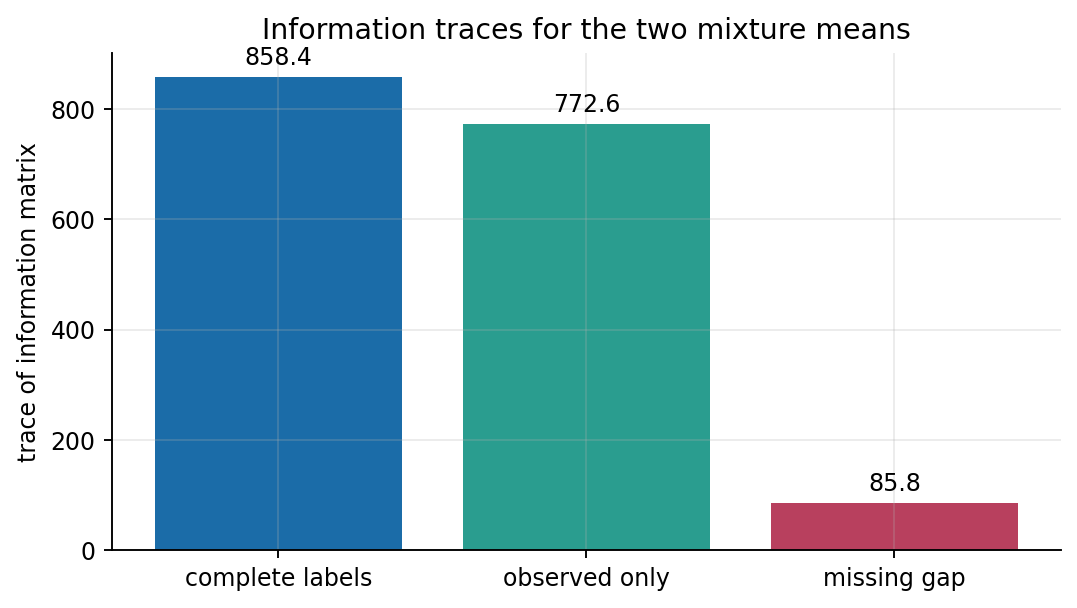

{'complete_trace': 858.3862288654325,
 'observed_trace': 772.6343173999339,
 'missing_trace': 85.7519114654985}

In [8]:
def observed_loglik_for_means(means, weights=final["weights"], sigmas=final["sigmas"]):
    comps = np.vstack([
        np.log(weights[j] + 1e-15) + norm.logpdf(x, means[j], sigmas[j])
        for j in range(2)
    ]).T
    return float(logsumexp(comps, axis=1).sum())

def finite_hessian_means(means, eps=1e-3):
    means = np.asarray(means, dtype=float)
    hess = np.zeros((2, 2))
    for i in range(2):
        for j in range(2):
            ei = np.zeros(2); ej = np.zeros(2)
            ei[i] = eps; ej[j] = eps
            hess[i, j] = (
                observed_loglik_for_means(means + ei + ej)
                - observed_loglik_for_means(means + ei - ej)
                - observed_loglik_for_means(means - ei + ej)
                + observed_loglik_for_means(means - ei - ej)
            ) / (4 * eps**2)
    return hess

observed_info = -finite_hessian_means(final["means"])
complete_info = np.diag(final["responsibilities"].sum(axis=0) / (final["sigmas"] ** 2))
missing_info = complete_info - observed_info

info_values = {
    "complete_trace": float(np.trace(complete_info)),
    "observed_trace": float(np.trace(observed_info)),
    "missing_trace": float(np.trace(missing_info)),
}

fig, ax = plt.subplots(figsize=(7.2, 3.8))
labels = ["complete labels", "observed only", "missing gap"]
vals = [info_values["complete_trace"], info_values["observed_trace"], info_values["missing_trace"]]
ax.bar(labels, vals, color=["#1b6ca8", "#2a9d8f", "#b8405e"])
ax.set_title("Information traces for the two mixture means")
ax.set_ylabel("trace of information matrix")
for idx, val in enumerate(vals):
    ax.text(idx, val + max(vals) * 0.025, f"{val:.1f}", ha="center", fontsize=10)
missing_info_bars = save_matplotlib(fig, CHAPTER, "missing-information", "information_trace_bars.png", dpi=170)
plt.close(fig)
display_artifact(missing_info_bars, width=760)
info_values


The observed information is smaller because some curvature is spent explaining uncertainty about labels. When clusters overlap, a shift in a mean changes both density and classification probabilities. EM handles that coupling by alternating rather than pretending the labels are known.


## 5. Coarse-Graining And Data Processing

Hidden variables are one kind of non-invertible observation map. Coarse-graining is another: several states are merged before the statistician sees them. KL divergence cannot increase under this merging. This is the data-processing statement behind many information-loss arguments: observing less can only make distributions harder to separate.


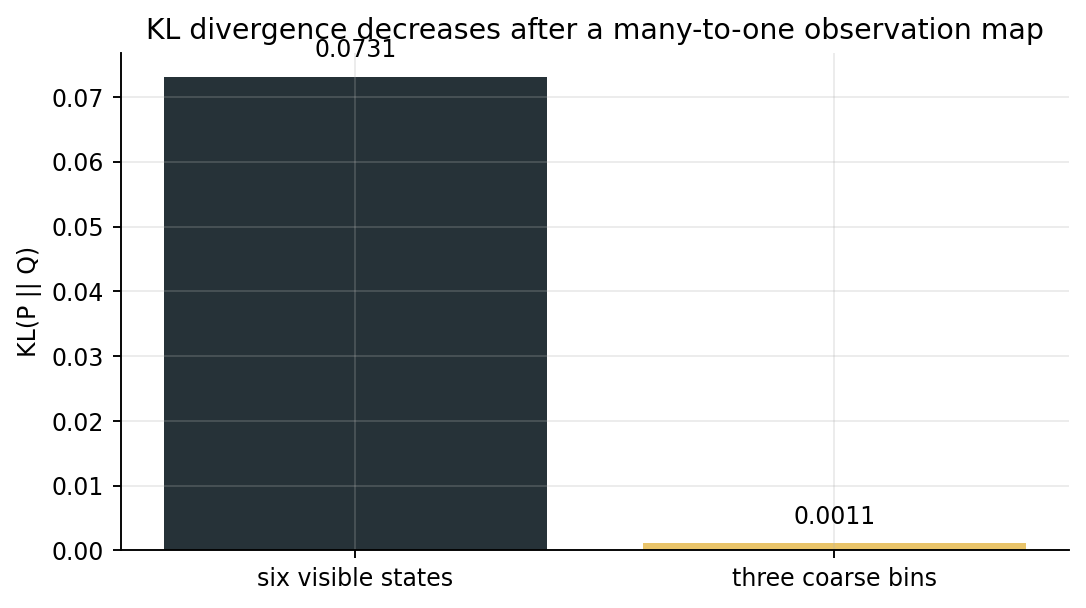

{'kl_full': 0.07314292430144892,
 'kl_coarse': 0.0010929932437811624,
 'loss': 0.07204993105766776}

In [9]:
def kl_discrete(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    mask = p > 0
    return float(np.sum(p[mask] * np.log(p[mask] / q[mask])))

p = np.array([0.06, 0.16, 0.28, 0.22, 0.18, 0.10])
q = np.array([0.12, 0.10, 0.18, 0.30, 0.17, 0.13])
blocks = [np.array([0, 1]), np.array([2, 3]), np.array([4, 5])]
P = np.array([p[b].sum() for b in blocks])
Q = np.array([q[b].sum() for b in blocks])
kl_full = kl_discrete(p, q)
kl_coarse = kl_discrete(P, Q)

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.bar(["six visible states", "three coarse bins"], [kl_full, kl_coarse], color=["#263238", "#e9c46a"])
ax.set_title("KL divergence decreases after a many-to-one observation map")
ax.set_ylabel("KL(P || Q)")
for i, val in enumerate([kl_full, kl_coarse]):
    ax.text(i, val + 0.003, f"{val:.4f}", ha="center")
coarse_kl_plot = save_matplotlib(fig, CHAPTER, "missing-information", "coarse_graining_kl.png", dpi=170)
plt.close(fig)
display_artifact(coarse_kl_plot, width=760)
{"kl_full": kl_full, "kl_coarse": kl_coarse, "loss": kl_full - kl_coarse}


This small calculation is deliberately finite. The same idea operates in continuous hidden-variable models, but the finite version makes the inequality visible without measure-theoretic machinery. A statistic is sufficient exactly when this kind of loss is absent for the family being studied.


## 6. Misspecification: Projection To The Closest Available Model

A hidden-variable model can still be wrong. If data come from a two-component mixture and we insist on a single Gaussian with fixed variance, the best mean is not a true component mean. It is the KL projection of the mixture onto the restricted model. With variance fixed, the optimum mean is the mixture average; the KL curve makes the projection literal.


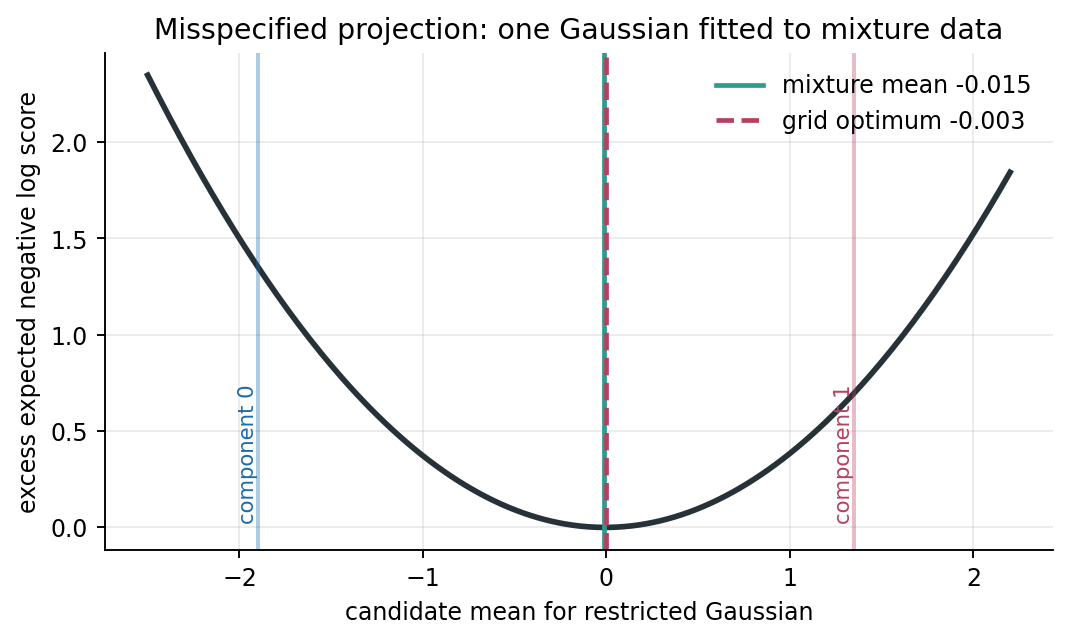

{'mixture_mean': -0.014999999999999902,
 'grid_optimum': -0.002510460251046176,
 'absolute_error': 0.012489539748953726}

In [10]:
true_weights = np.array([0.42, 0.58])
true_means = np.array([-1.9, 1.35])
true_sigmas = np.array([0.58, 0.82])
fixed_sigma = 1.15
mixture_mean = float(np.dot(true_weights, true_means))
mu_grid = np.linspace(-2.5, 2.2, 240)

sample_large, _ = simulate_mixture(n=80000, weights=true_weights, means=true_means, sigmas=true_sigmas, rng=np.random.default_rng(88))
# KL(true mixture || Normal(mu, fixed_sigma)) differs from the negative expected log score by a constant.
kl_curve = np.array([-np.mean(norm.logpdf(sample_large, mu, fixed_sigma)) for mu in mu_grid])
mu_hat_grid = float(mu_grid[np.argmin(kl_curve)])

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.plot(mu_grid, kl_curve - kl_curve.min(), color="#263238", lw=2.4)
ax.axvline(mixture_mean, color="#2a9d8f", lw=2, label=f"mixture mean {mixture_mean:.3f}")
ax.axvline(mu_hat_grid, color="#b8405e", lw=2, ls="--", label=f"grid optimum {mu_hat_grid:.3f}")
for m, label, color in zip(true_means, ["component 0", "component 1"], ["#1b6ca8", "#b8405e"]):
    ax.axvline(m, color=color, alpha=0.35, lw=1.7)
    ax.text(m, 0.02, label, rotation=90, va="bottom", ha="right", color=color, fontsize=9)
ax.set_title("Misspecified projection: one Gaussian fitted to mixture data")
ax.set_xlabel("candidate mean for restricted Gaussian")
ax.set_ylabel("excess expected negative log score")
ax.legend(frameon=False)
misspec_curve = save_matplotlib(fig, CHAPTER, "misspecification", "single_gaussian_projection.png", dpi=170)
plt.close(fig)
display_artifact(misspec_curve, width=760)
{"mixture_mean": mixture_mean, "grid_optimum": mu_hat_grid, "absolute_error": abs(mixture_mean - mu_hat_grid)}


Misspecification changes the target. In a correctly specified regular model, estimation tries to recover the parameter that generated the data. In a misspecified model, the parameter is a shadow point: the member of the chosen family that is closest to the truth by the relevant divergence. This is why model checking is not an optional final polish. It determines what the estimator means.


## Applied Lab: How Overlap Changes EM

Use this cell as a small experiment. Increasing `overlap_scale` moves the component means closer and inflates the component standard deviations. The expected changes are geometric: responsibilities become less decisive, the missing-information gap grows, and the log-likelihood trace often needs more iterations to settle.


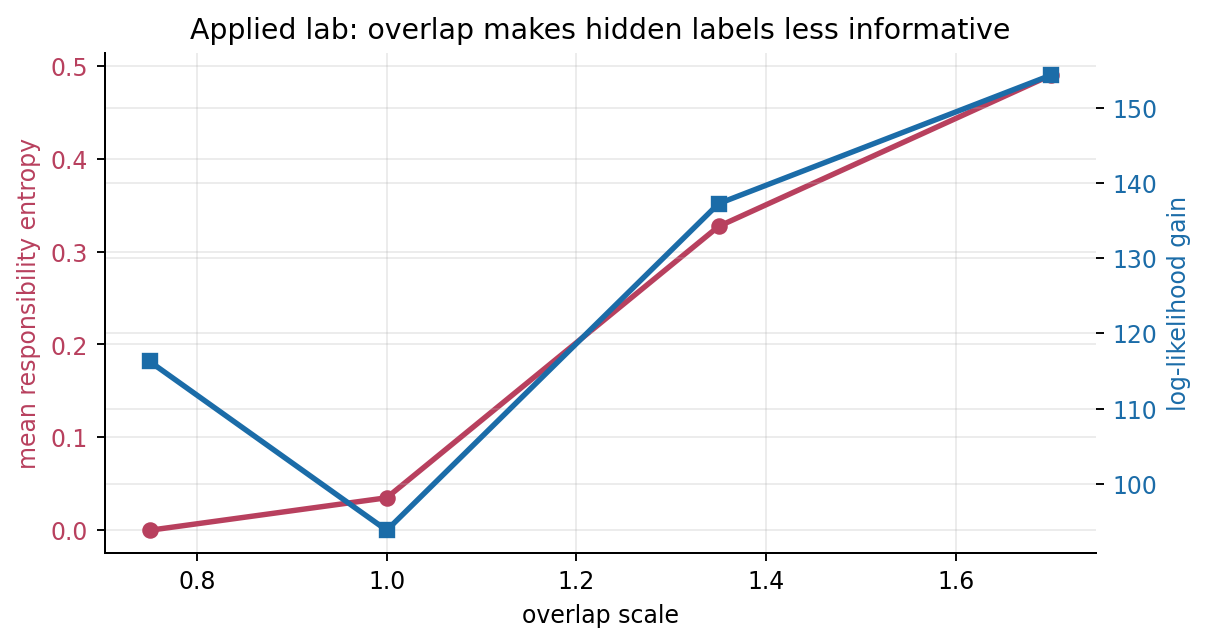

[{'overlap_scale': 0.75,
  'final_means': [-2.5239, 1.72],
  'responsibility_entropy': 3.600575120442879e-05,
  'loglik_gain': 116.26248862621867,
  'iterations': 28},
 {'overlap_scale': 1.0,
  'final_means': [-1.8925, 1.2551],
  'responsibility_entropy': 0.03503686635545952,
  'loglik_gain': 93.80707080608215,
  'iterations': 28},
 {'overlap_scale': 1.35,
  'final_means': [-1.3031, 0.8877],
  'responsibility_entropy': 0.3270362399312719,
  'loglik_gain': 137.26141582049638,
  'iterations': 28},
 {'overlap_scale': 1.7,
  'final_means': [-0.9002, 0.8145],
  'responsibility_entropy': 0.4895763493156126,
  'loglik_gain': 154.32673994948982,
  'iterations': 28}]

In [11]:
def run_overlap_lab(overlap_scale=1.0, n=320, seed=808):
    rng = np.random.default_rng(seed)
    means = np.array([-1.9, 1.35]) / overlap_scale
    sigmas = np.array([0.58, 0.82]) * overlap_scale
    x_lab, _ = simulate_mixture(n=n, means=means, sigmas=sigmas, rng=rng)
    hist = em_gmm_1d(x_lab, iterations=28, init_means=(-2.3, 2.0), init_sigmas=(1.1, 1.1))
    resp = hist[-1]["responsibilities"]
    entropy = float(-np.mean(np.sum(resp * np.log(resp + 1e-15), axis=1)))
    ll_gain = float(hist[-1]["loglik"] - hist[0]["loglik"])
    return {
        "overlap_scale": overlap_scale,
        "final_means": hist[-1]["means"].round(4).tolist(),
        "responsibility_entropy": entropy,
        "loglik_gain": ll_gain,
        "iterations": len(hist) - 1,
    }

lab_results = [run_overlap_lab(s) for s in [0.75, 1.0, 1.35, 1.7]]
fig, ax0 = plt.subplots(figsize=(7.2, 3.9))
scales = [r["overlap_scale"] for r in lab_results]
entropies = [r["responsibility_entropy"] for r in lab_results]
gains = [r["loglik_gain"] for r in lab_results]
ax0.plot(scales, entropies, marker="o", color="#b8405e", lw=2.3, label="responsibility entropy")
ax0.set_xlabel("overlap scale")
ax0.set_ylabel("mean responsibility entropy", color="#b8405e")
ax0.tick_params(axis="y", labelcolor="#b8405e")
ax1 = ax0.twinx()
ax1.plot(scales, gains, marker="s", color="#1b6ca8", lw=2.3, label="log-likelihood gain")
ax1.set_ylabel("log-likelihood gain", color="#1b6ca8")
ax1.tick_params(axis="y", labelcolor="#1b6ca8")
ax0.set_title("Applied lab: overlap makes hidden labels less informative")
fig.tight_layout()
overlap_lab_plot = save_matplotlib(fig, CHAPTER, "applied-lab", "overlap_lab.png", dpi=170)
plt.close(fig)
display_artifact(overlap_lab_plot, width=760)
lab_results


## Takeaways

- EM is easiest to reason about after lifting the problem to complete data: the E-step chooses hidden completions and the M-step refits the complete-data model.
- Gaussian mixtures turn hidden labels into responsibilities. The overlap region is where missing information lives.
- The observed log likelihood rises in the demonstration because each EM cycle optimizes a local auxiliary problem.
- Coarse-graining decreases KL divergence, so hidden variables and many-to-one summaries can erase distinguishability.
- Under misspecification, the estimator targets the closest model point rather than the literal truth.


## Final Sanity Checks

The final cell records the chapter checks as JSON and asserts the identities that this notebook depends on: normalized responsibilities, monotone EM trace, KL contraction under coarse-graining, misspecified projection near the mixture mean, and nonempty generated artifacts.


In [12]:
artifacts = [
    projection_diagram,
    raw_data_plot,
    responsibility_heatmap,
    loglik_trace,
    likelihood_surface,
    missing_info_bars,
    coarse_kl_plot,
    misspec_curve,
    overlap_lab_plot,
]
records = [artifact_record(p) for p in artifacts]

checks = {
    "responsibilities_sum_to_one": bool(np.allclose(final["responsibilities"].sum(axis=1), 1.0, atol=1e-10)),
    "em_loglik_non_decreasing": bool(np.all(np.diff(loglik) >= -1e-8)),
    "coarse_grained_kl_not_larger": bool(kl_coarse <= kl_full + 1e-12),
    "observed_information_no_larger_than_complete_trace": bool(info_values["observed_trace"] <= info_values["complete_trace"] + 1e-6),
    "misspecified_projection_near_mixture_mean": bool(abs(mixture_mean - mu_hat_grid) < 0.03),
    "artifact_count": len(records),
    "all_artifacts_nonempty": bool(all(r["exists"] and r["bytes"] > 1000 for r in records)),
}

sanity = {
    "chapter": "08-hidden-variables-and-em",
    "source_orientation": {"printed_pages": "179-189", "pdf_pages": "186-196"},
    "checks": checks,
    "em_final": {
        "weights": final["weights"].round(6).tolist(),
        "means": final["means"].round(6).tolist(),
        "sigmas": final["sigmas"].round(6).tolist(),
        "loglik": float(final["loglik"]),
    },
    "information": info_values,
    "coarse_graining": {"kl_full": kl_full, "kl_coarse": kl_coarse, "loss": kl_full - kl_coarse},
    "misspecification": {"mixture_mean": mixture_mean, "grid_optimum": mu_hat_grid},
    "artifacts": records,
}

sanity_path = save_json(sanity, CHAPTER, "sanity", "chapter_08_sanity.json")
for name, passed in checks.items():
    if isinstance(passed, bool):
        assert passed, name

print(json.dumps({"sanity_json": artifact_record(sanity_path), "checks": checks}, indent=2))


{
  "sanity_json": {
    "path": "artifacts/chapter-08/sanity/chapter_08_sanity.json",
    "exists": true,
    "bytes": 2409
  },
  "checks": {
    "responsibilities_sum_to_one": true,
    "em_loglik_non_decreasing": true,
    "coarse_grained_kl_not_larger": true,
    "observed_information_no_larger_than_complete_trace": true,
    "misspecified_projection_near_mixture_mean": true,
    "artifact_count": 9,
    "all_artifacts_nonempty": true
  }
}


## Standalone Synthesis

The chapter focus is: EM as alternating divergence minimization, hidden-variable models, Gaussian mixtures, information loss under data reduction, and misspecification.

Key computational translations:

- hidden variables enlarge the complete-data manifold. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- EM alternates between compatible observed-data and model constraints. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- data reduction loses information when the statistic is insufficient. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.
- misspecification replaces truth with the closest model point. In the notebook this is represented by a concrete array, curve, surface, or metric object, then checked numerically so the reader can see the invariant rather than infer it from prose alone.

How to read the visual sequence:

- two-manifold EM projection diagram. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- Gaussian-mixture responsibility heatmap. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- monotone log-likelihood trace through EM iterations. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.
- coarse-graining information-loss bar chart. This visual should be read as evidence for a geometric claim, not as decoration; the surrounding code records the quantities that make the claim testable.

This standalone synthesis is intentionally explicit about the contract between explanation, computation, and artifact. The reader should be able to close the PDF and still reconstruct the chapter's working picture: what the objects are, which coordinates are being used, what the visual is meant to reveal, and which numerical check guards the interpretation. When a divergence, metric, projection, or learning path appears, the notebook treats it as an inspectable mechanism. Changing the toy parameters is part of the lesson because it separates robust geometric behavior from an accidental drawing. If the saved check remains stable, the picture is carrying the idea; if the check fails, the diagram has become misleading and the model assumptions need to be revisited.


## Course Standard Note

**Source span:** printed pages 179-189; PDF pages 186-196. The PDF is used only for source orientation, not as a required companion while reading this standalone notebook. The final_sanity evidence for this chapter is stored under `artifacts/chapter-08` using the chapter's local sanity JSON naming convention.
